In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Import your Part 1 implementations

class KMeans:
    """
    K-Means Clustering implementation from scratch using only NumPy.
    
    Parameters:
    -----------
    n_clusters : int
        Number of clusters to form
    init : str, default='k-means++'
        Initialization method: 'k-means++' or 'random'
    max_iter : int, default=300
        Maximum number of iterations
    tol : float, default=1e-4
        Tolerance for convergence (change in centroids)
    random_state : int, default=None
        Random seed for reproducibility
    """
    
    def __init__(self, n_clusters=8, init='k-means++', max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.init = init
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        
        # Results
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None
        self.inertia_history_ = []
        self.n_iter_ = 0
        
    def _initialize_centroids(self, X):
        """Initialize centroids using specified method."""
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        
        if self.init == 'random':
            # Random initialization: randomly select k points from data
            indices = np.random.choice(n_samples, self.n_clusters, replace=False)
            centroids = X[indices].copy()
            
        elif self.init == 'k-means++':
            # K-Means++ initialization
            centroids = np.zeros((self.n_clusters, n_features))
            
            # Choose first centroid randomly
            centroids[0] = X[np.random.choice(n_samples)]
            
            # Choose remaining centroids
            for i in range(1, self.n_clusters):
                # Calculate distances from each point to nearest existing centroid
                distances = np.array([min([np.linalg.norm(x - c)**2 for c in centroids[:i]]) 
                                     for x in X])
                
                # Choose next centroid with probability proportional to distance squared
                probabilities = distances / distances.sum()
                cumulative_probs = probabilities.cumsum()
                r = np.random.rand()
                
                for j, cum_prob in enumerate(cumulative_probs):
                    if r < cum_prob:
                        centroids[i] = X[j]
                        break
        else:
            raise ValueError(f"Unknown initialization method: {self.init}")
            
        return centroids
    
    def _assign_clusters(self, X, centroids):
        """Assign each data point to nearest centroid."""
        n_samples = X.shape[0]
        labels = np.zeros(n_samples, dtype=int)
        
        for i in range(n_samples):
            # Calculate distances to all centroids
            distances = np.linalg.norm(X[i] - centroids, axis=1)
            # Assign to nearest centroid
            labels[i] = np.argmin(distances)
            
        return labels
    
    def _update_centroids(self, X, labels):
        """Update centroids as mean of assigned points."""
        n_features = X.shape[1]
        centroids = np.zeros((self.n_clusters, n_features))
        
        for k in range(self.n_clusters):
            # Get all points assigned to cluster k
            cluster_points = X[labels == k]
            
            if len(cluster_points) > 0:
                # Update centroid as mean of cluster points
                centroids[k] = cluster_points.mean(axis=0)
            else:
                # If cluster is empty, reinitialize randomly
                centroids[k] = X[np.random.choice(X.shape[0])]
                
        return centroids
    
    def _compute_inertia(self, X, labels, centroids):
        """Compute within-cluster sum of squared distances (inertia/WCSS)."""
        inertia = 0.0
        for k in range(self.n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                inertia += np.sum((cluster_points - centroids[k])**2)
        return inertia
    
    def fit(self, X):
        """
        Fit K-Means clustering.
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Training data
            
        Returns:
        --------
        self : object
            Fitted estimator
        """
        # Initialize centroids
        self.centroids = self._initialize_centroids(X)
        self.inertia_history_ = []
        
        # Iterative optimization
        for iteration in range(self.max_iter):
            # Assign points to nearest centroids
            labels = self._assign_clusters(X, self.centroids)
            
            # Update centroids
            new_centroids = self._update_centroids(X, labels)
            
            # Compute inertia
            inertia = self._compute_inertia(X, labels, new_centroids)
            self.inertia_history_.append(inertia)
            
            # Check for convergence
            centroid_shift = np.linalg.norm(new_centroids - self.centroids)
            
            self.centroids = new_centroids
            self.n_iter_ = iteration + 1
            
            if centroid_shift < self.tol:
                break
        
        # Final assignment
        self.labels_ = self._assign_clusters(X, self.centroids)
        self.inertia_ = self._compute_inertia(X, self.labels_, self.centroids)
        
        return self
    
    def predict(self, X):
        """
        Predict cluster labels for data.
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Data to predict
            
        Returns:
        --------
        labels : array, shape (n_samples,)
            Cluster labels
        """
        if self.centroids is None:
            raise ValueError("Model not fitted yet. Call fit() first.")
            
        return self._assign_clusters(X, self.centroids)
    
    def fit_predict(self, X):
        """Fit and return cluster labels."""
        self.fit(X)
        return self.labels_


# Example usage and testing
if __name__ == "__main__":
    # Generate sample data for testing
    np.random.seed(42)
    
    # Create 3 clusters of data
    cluster1 = np.random.randn(100, 2) + np.array([0, 0])
    cluster2 = np.random.randn(100, 2) + np.array([5, 5])
    cluster3 = np.random.randn(100, 2) + np.array([10, 0])
    X = np.vstack([cluster1, cluster2, cluster3])
    
    # Test K-Means++ initialization
    print("Testing K-Means with K-Means++ initialization:")
    kmeans_pp = KMeans(n_clusters=3, init='k-means++', random_state=42)
    kmeans_pp.fit(X)
    print(f"Converged in {kmeans_pp.n_iter_} iterations")
    print(f"Final inertia: {kmeans_pp.inertia_:.2f}")
    print(f"Centroids shape: {kmeans_pp.centroids.shape}")
    print()
    
    # Test random initialization
    print("Testing K-Means with random initialization:")
    kmeans_rand = KMeans(n_clusters=3, init='random', random_state=42)
    kmeans_rand.fit(X)
    print(f"Converged in {kmeans_rand.n_iter_} iterations")
    print(f"Final inertia: {kmeans_rand.inertia_:.2f}")
    print()
    
    # Compare convergence speed
    print("Inertia history comparison:")
    print(f"K-Means++: {len(kmeans_pp.inertia_history_)} iterations")
    print(f"Random: {len(kmeans_rand.inertia_history_)} iterations")
    print()
    
    # Test prediction on new data
    new_points = np.array([[0, 0], [5, 5], [10, 0]])
    predictions = kmeans_pp.predict(new_points)
    print(f"Predictions for new points: {predictions}")

Testing K-Means with K-Means++ initialization:
Converged in 3 iterations
Final inertia: 561.18
Centroids shape: (3, 2)

Testing K-Means with random initialization:
Converged in 8 iterations
Final inertia: 561.18

Inertia history comparison:
K-Means++: 3 iterations
Random: 8 iterations

Predictions for new points: [2 0 1]


Data loaded and standardized!
Shape: (569, 30)

EXPERIMENT 1: K-MEANS ON ORIGINAL DATA

Finding optimal k using elbow method and silhouette analysis...
k=2: K-Means++ WCSS=11595.53, Silhouette=0.343, Iters=4
      Random    WCSS=11595.68, Silhouette=0.345, Iters=9
k=3: K-Means++ WCSS=10061.80, Silhouette=0.314, Iters=10
      Random    WCSS=10061.80, Silhouette=0.314, Iters=9
k=4: K-Means++ WCSS=9339.39, Silhouette=0.157, Iters=6
      Random    WCSS=9409.83, Silhouette=0.250, Iters=15
k=5: K-Means++ WCSS=8885.01, Silhouette=0.143, Iters=9
      Random    WCSS=8564.40, Silhouette=0.168, Iters=16
k=6: K-Means++ WCSS=8394.43, Silhouette=0.148, Iters=9
      Random    WCSS=8171.85, Silhouette=0.159, Iters=24
k=7: K-Means++ WCSS=7849.31, Silhouette=0.132, Iters=15
      Random    WCSS=7763.15, Silhouette=0.158, Iters=13
k=8: K-Means++ WCSS=7276.95, Silhouette=0.143, Iters=20
      Random    WCSS=7599.01, Silhouette=0.144, Iters=14
k=9: K-Means++ WCSS=7364.37, Silhouette=0.136, Iters=25
   

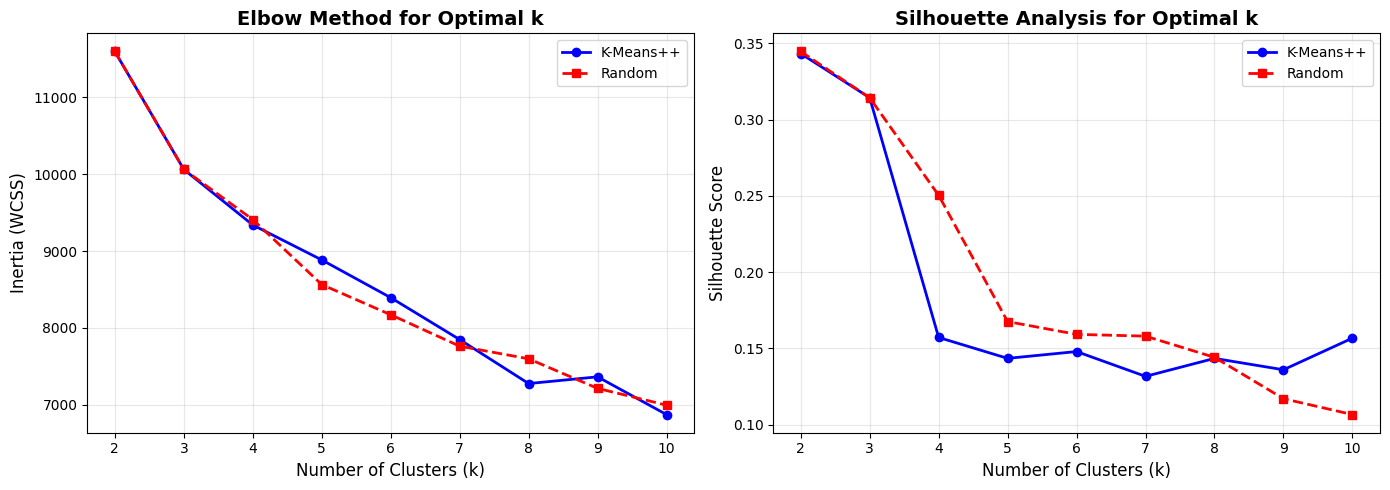

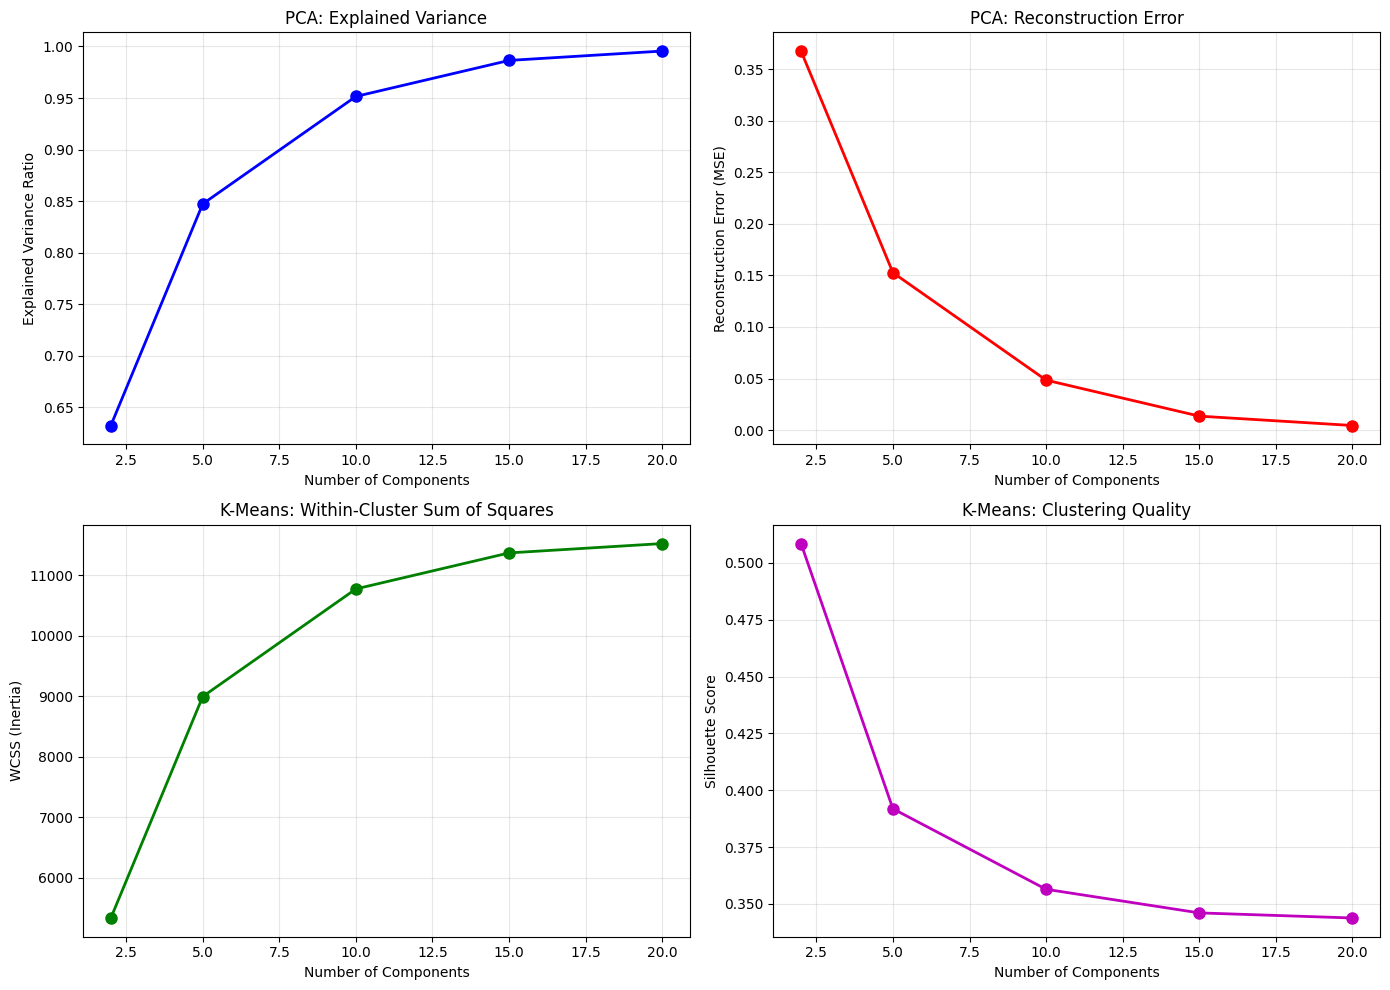

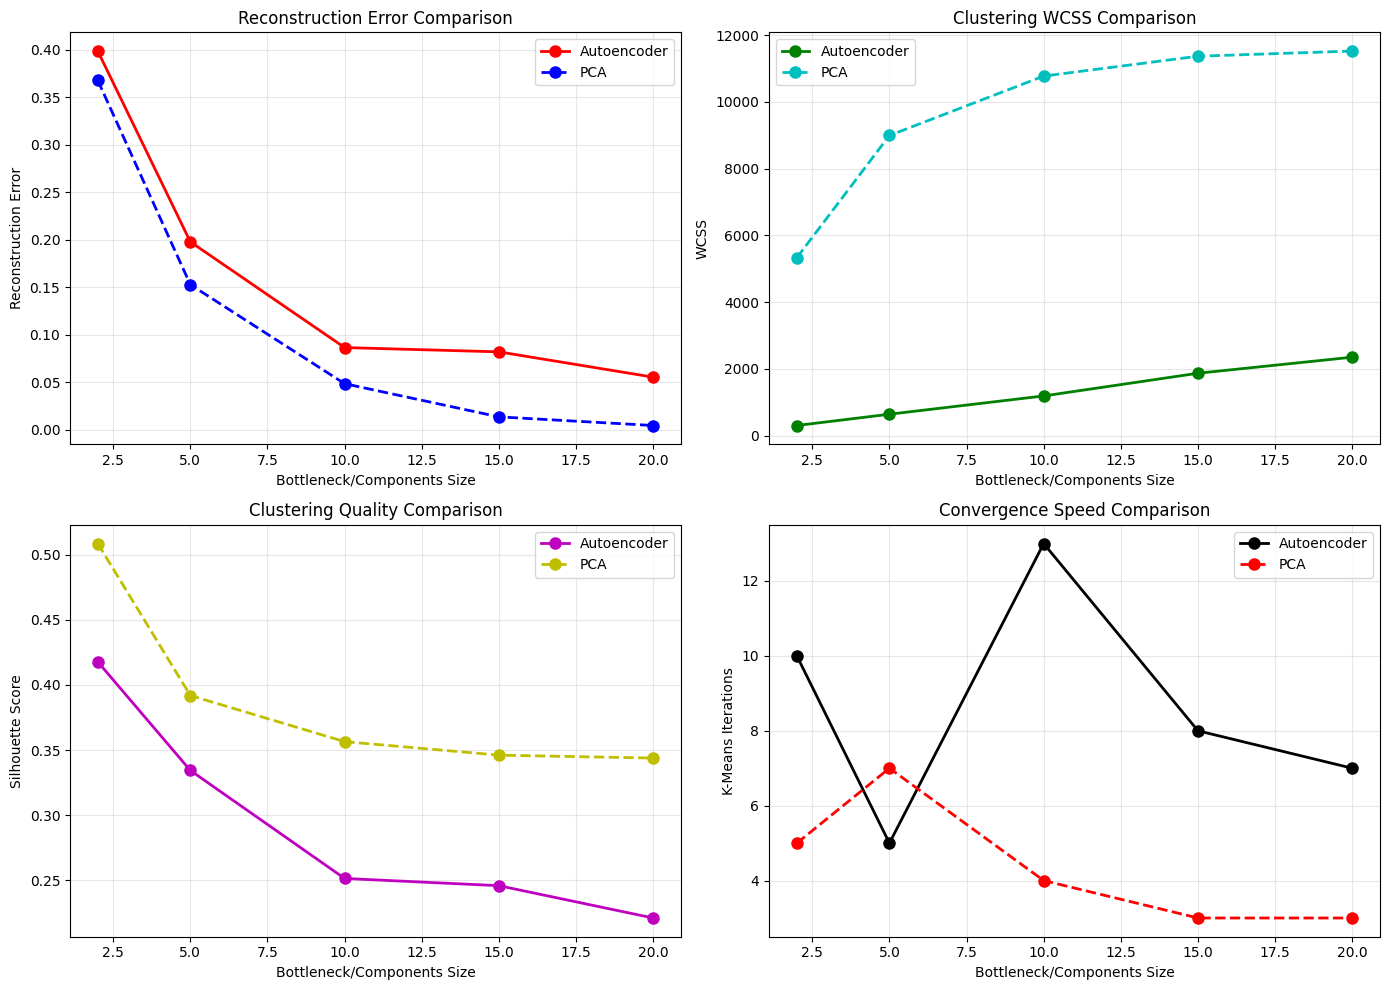

In [ ]:

# ===== HELPER FUNCTIONS =====

def calculate_silhouette_score(X, labels):
    """Calculate silhouette score for clustering."""
    n_samples = len(X)
    n_clusters = len(np.unique(labels))
    silhouette_scores = np.zeros(n_samples)
    
    for i in range(n_samples):
        # Points in same cluster
        same_cluster = X[labels == labels[i]]
        if len(same_cluster) > 1:
            a = np.mean([np.linalg.norm(X[i] - x) for x in same_cluster if not np.array_equal(X[i], x)])
        else:
            a = 0
        
        # Points in nearest different cluster
        b = np.inf
        for k in range(n_clusters):
            if k != labels[i]:
                other_cluster = X[labels == k]
                if len(other_cluster) > 0:
                    dist = np.mean([np.linalg.norm(X[i] - x) for x in other_cluster])
                    b = min(b, dist)
        
        if b == np.inf:
            silhouette_scores[i] = 0
        else:
            silhouette_scores[i] = (b - a) / max(a, b)
    
    return np.mean(silhouette_scores)

def gap_statistic(X, labels, n_refs=10, random_state=42):
    """Calculate gap statistic for optimal k."""
    np.random.seed(random_state)
    
    # Calculate WCSS for actual clustering
    n_clusters = len(np.unique(labels))
    wcss_actual = 0
    for k in range(n_clusters):
        cluster_points = X[labels == k]
        if len(cluster_points) > 0:
            centroid = cluster_points.mean(axis=0)
            wcss_actual += np.sum((cluster_points - centroid)**2)
    
    # Calculate WCSS for reference datasets
    wcss_refs = []
    for _ in range(n_refs):
        # Generate random data in same bounds
        X_random = np.random.uniform(X.min(axis=0), X.max(axis=0), X.shape)
        
        # Apply K-Means to random data
        kmeans_ref = KMeans(n_clusters=n_clusters, random_state=random_state)
        kmeans_ref.fit(X_random)
        wcss_refs.append(kmeans_ref.inertia_)
    
    # Gap statistic
    gap = np.log(np.mean(wcss_refs)) - np.log(wcss_actual)
    return gap

# ===== LOAD DATA =====

breast = load_breast_cancer()
X = breast.data
y = breast.target
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

print("Data loaded and standardized!")
print(f"Shape: {X.shape}")
print()

# ===== YOUR PCA IMPLEMENTATION =====

class PCA:
    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        cov = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        idx = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[idx]
        self.eigenvectors = eigenvectors[:, idx]
        self.components = self.eigenvectors[:, :self.n_components]
        self.explained_variance_ratio = (
            self.eigenvalues[:self.n_components] / np.sum(self.eigenvalues)
        )

    def transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def inverse_transform(self, X_reduced):
        return np.dot(X_reduced, self.components.T) + self.mean

    def reconstruction_error(self, X):
        X_recon = self.inverse_transform(self.transform(X))
        return np.mean((X - X_recon) ** 2)

# ===== YOUR AUTOENCODER IMPLEMENTATION =====

def tanh(x):
    return np.tanh(x)

def tanh_deriv(x):
    return 1 - np.tanh(x) ** 2

class Autoencoder:
    def __init__(self, layer_sizes, lr=0.005, l2=1e-4):
        self.layer_sizes = layer_sizes
        self.lr = lr
        self.l2 = l2
        self.weights = []
        self.biases = []
        
        for i in range(len(layer_sizes) - 1):
            if i == len(layer_sizes) - 2:
                W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01
            else:
                W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(1 / layer_sizes[i])
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights.append(W)
            self.biases.append(b)

    def forward(self, X):
        activations = [X]
        zs = []
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            z = activations[-1] @ W + b
            zs.append(z)
            if i == len(self.weights) - 1:
                activations.append(z)
            else:
                activations.append(tanh(z))
        return activations, zs

    def backward(self, X, activations, zs):
        grads_W = [None] * len(self.weights)
        grads_b = [None] * len(self.biases)
        delta = activations[-1] - X
        for i in reversed(range(len(self.weights))):
            grads_W[i] = activations[i].T @ delta + self.l2 * self.weights[i]
            grads_b[i] = np.sum(delta, axis=0, keepdims=True)
            if i > 0:
                delta = (delta @ self.weights[i].T) * tanh_deriv(zs[i-1])
        return grads_W, grads_b

    def train(self, X, epochs=150, batch_size=32, lr_decay=0.995, verbose=True):
        n = X.shape[0]
        loss_history = []
        
        for epoch in range(epochs):
            perm = np.random.permutation(n)
            X_shuffled = X[perm]
            for i in range(0, n, batch_size):
                batch = X_shuffled[i:i + batch_size]
                activations, zs = self.forward(batch)
                grads_W, grads_b = self.backward(batch, activations, zs)
                for j in range(len(self.weights)):
                    self.weights[j] -= self.lr * grads_W[j]
                    self.biases[j] -= self.lr * grads_b[j]
            
            self.lr *= lr_decay
            loss = np.mean((self.forward(X)[0][-1] - X) ** 2)
            loss_history.append(loss)
            
            if verbose and epoch % 30 == 0:
                print(f"Epoch {epoch}, Loss = {loss:.5f}")
        
        return loss_history

    def encode(self, X):
        activations, _ = self.forward(X)
        return activations[len(self.layer_sizes) // 2]

    def reconstruct(self, X):
        return self.forward(X)[0][-1]

# ===== EXPERIMENT 1: K-MEANS ON ORIGINAL DATA =====

print("="*60)
print("EXPERIMENT 1: K-MEANS ON ORIGINAL DATA")
print("="*60)
gap_scores_pp = []
gap_scores_rand = []

# Test different k values for elbow method
k_values = range(2, 11)
inertias_pp = []
inertias_rand = []
silhouette_scores_pp = []
silhouette_scores_rand = []

print("\nFinding optimal k using elbow method and silhouette analysis...")

for k in k_values:
    # K-Means++
    kmeans_pp = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans_pp.fit(X)
    inertias_pp.append(kmeans_pp.inertia_)
    sil_pp = calculate_silhouette_score(X, kmeans_pp.labels_)
    silhouette_scores_pp.append(sil_pp)
    
    # Random initialization
    kmeans_rand = KMeans(n_clusters=k, init='random', random_state=42)
    kmeans_rand.fit(X)
    inertias_rand.append(kmeans_rand.inertia_)
    sil_rand = calculate_silhouette_score(X, kmeans_rand.labels_)
    silhouette_scores_rand.append(sil_rand)
    
    # Compute Gap Statistic for K-Means++ clustering
    gap_pp = gap_statistic(X, kmeans_pp.labels_, n_refs=10, random_state=42)
    gap_scores_pp.append(gap_pp)
    gap_rand = gap_statistic(X, kmeans_rand.labels_, n_refs=10, random_state=42)
    gap_scores_rand.append(gap_rand)
    print(f"k={k}: K-Means++ WCSS={kmeans_pp.inertia_:.2f}, Silhouette={sil_pp:.3f}, Iters={kmeans_pp.n_iter_}")
    print(f"      Random    WCSS={kmeans_rand.inertia_:.2f}, Silhouette={sil_rand:.3f}, Iters={kmeans_rand.n_iter_}")
    print(f"k={k}: K-Means++ WCSS={kmeans_pp.inertia_:.2f}, Silhouette={sil_pp:.3f}, Gap={gap_pp:.3f}, Iters={kmeans_pp.n_iter_}")
    print(f"      Random    WCSS={kmeans_rand.inertia_:.2f}, Silhouette={sil_rand:.3f}, Gap={gap_rand:.3f}, Iters={kmeans_rand.n_iter_}")

# Plot elbow curve
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias_pp, 'bo-', label='K-Means++', linewidth=2)
plt.plot(k_values, inertias_rand, 'rs--', label='Random', linewidth=2)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores_pp, 'bo-', label='K-Means++', linewidth=2)
plt.plot(k_values, silhouette_scores_rand, 'rs--', label='Random', linewidth=2)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Analysis for Optimal k', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Gap Statistic
plt.subplot(1, 3, 3)
plt.plot(k_values, gap_scores_pp, 'bo-', label='K-Means++')
plt.plot(k_values, gap_scores_rand, 'rs--', label='Random')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic Analysis')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment1_elbow_silhouette.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: experiment1_elbow_silhouette.png")

# Best k based on silhouette score
optimal_k = k_values[np.argmax(silhouette_scores_pp)]
print(f"\n✓ Optimal k based on silhouette score: {optimal_k}")

# ===== EXPERIMENT 3: K-MEANS AFTER PCA =====

print("\n" + "="*60)
print("EXPERIMENT 3: K-MEANS AFTER PCA")
print("="*60)

n_components_list = [2, 5, 10, 15, 20]
results_pca_kmeans = []

for n_comp in n_components_list:
    print(f"\n--- PCA with {n_comp} components ---")
    
    # Apply PCA
    pca = PCA(n_components=n_comp)
    pca.fit(X)
    X_pca = pca.transform(X)
    recon_error = pca.reconstruction_error(X)
    
    print(f"Explained Variance: {np.sum(pca.explained_variance_ratio):.3f}")
    print(f"Reconstruction Error: {recon_error:.5f}")
    
    # Apply K-Means
    kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
    kmeans.fit(X_pca)
    
    sil_score = calculate_silhouette_score(X_pca, kmeans.labels_)
    
    print(f"K-Means Results: WCSS={kmeans.inertia_:.2f}, Silhouette={sil_score:.3f}, Iters={kmeans.n_iter_}")
    
    results_pca_kmeans.append({
        'n_components': n_comp,
        'explained_var': np.sum(pca.explained_variance_ratio),
        'recon_error': recon_error,
        'wcss': kmeans.inertia_,
        'silhouette': sil_score,
        'n_iter': kmeans.n_iter_
    })

# Results table
df_pca_kmeans = pd.DataFrame(results_pca_kmeans)
print("\n" + "="*60)
print("PCA + K-Means Results Summary:")
print("="*60)
print(df_pca_kmeans.to_string(index=False))

# Plot trade-offs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(n_components_list, df_pca_kmeans['explained_var'], 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Components')
axes[0, 0].set_ylabel('Explained Variance Ratio')
axes[0, 0].set_title('PCA: Explained Variance')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(n_components_list, df_pca_kmeans['recon_error'], 'ro-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Components')
axes[0, 1].set_ylabel('Reconstruction Error (MSE)')
axes[0, 1].set_title('PCA: Reconstruction Error')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(n_components_list, df_pca_kmeans['wcss'], 'go-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Components')
axes[1, 0].set_ylabel('WCSS (Inertia)')
axes[1, 0].set_title('K-Means: Within-Cluster Sum of Squares')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(n_components_list, df_pca_kmeans['silhouette'], 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Components')
axes[1, 1].set_ylabel('Silhouette Score')
axes[1, 1].set_title('K-Means: Clustering Quality')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment3_pca_kmeans.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: experiment3_pca_kmeans.png")

# ===== EXPERIMENT 5: K-MEANS AFTER AUTOENCODER =====

print("\n" + "="*60)
print("EXPERIMENT 5: K-MEANS AFTER AUTOENCODER")
print("="*60)

bottleneck_sizes = [2, 5, 10, 15, 20]
results_ae_kmeans = []

for bottleneck in bottleneck_sizes:
    print(f"\n--- Autoencoder with bottleneck={bottleneck} ---")
    
    # Build autoencoder architecture
    layer_sizes = [30, 20, bottleneck, 20, 30]
    
    # Train autoencoder
    ae = Autoencoder(layer_sizes, lr=0.005, l2=1e-4)
    print("Training autoencoder...")
    loss_history = ae.train(X, epochs=150, batch_size=32, verbose=False)
    
    # Encode data
    X_encoded = ae.encode(X)
    X_recon = ae.reconstruct(X)
    recon_error = np.mean((X - X_recon) ** 2)
    
    print(f"Final Training Loss: {loss_history[-1]:.5f}")
    print(f"Reconstruction Error: {recon_error:.5f}")
    
    # Apply K-Means
    kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
    kmeans.fit(X_encoded)
    
    sil_score = calculate_silhouette_score(X_encoded, kmeans.labels_)
    
    print(f"K-Means Results: WCSS={kmeans.inertia_:.2f}, Silhouette={sil_score:.3f}, Iters={kmeans.n_iter_}")
    
    results_ae_kmeans.append({
        'bottleneck': bottleneck,
        'final_loss': loss_history[-1],
        'recon_error': recon_error,
        'wcss': kmeans.inertia_,
        'silhouette': sil_score,
        'n_iter': kmeans.n_iter_
    })

# Results table
df_ae_kmeans = pd.DataFrame(results_ae_kmeans)
print("\n" + "="*60)
print("Autoencoder + K-Means Results Summary:")
print("="*60)
print(df_ae_kmeans.to_string(index=False))

# Comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(bottleneck_sizes, df_ae_kmeans['recon_error'], 'ro-', linewidth=2, markersize=8, label='Autoencoder')
axes[0, 0].plot(n_components_list, df_pca_kmeans['recon_error'], 'bo--', linewidth=2, markersize=8, label='PCA')
axes[0, 0].set_xlabel('Bottleneck/Components Size')
axes[0, 0].set_ylabel('Reconstruction Error')
axes[0, 0].set_title('Reconstruction Error Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(bottleneck_sizes, df_ae_kmeans['wcss'], 'go-', linewidth=2, markersize=8, label='Autoencoder')
axes[0, 1].plot(n_components_list, df_pca_kmeans['wcss'], 'co--', linewidth=2, markersize=8, label='PCA')
axes[0, 1].set_xlabel('Bottleneck/Components Size')
axes[0, 1].set_ylabel('WCSS')
axes[0, 1].set_title('Clustering WCSS Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(bottleneck_sizes, df_ae_kmeans['silhouette'], 'mo-', linewidth=2, markersize=8, label='Autoencoder')
axes[1, 0].plot(n_components_list, df_pca_kmeans['silhouette'], 'yo--', linewidth=2, markersize=8, label='PCA')
axes[1, 0].set_xlabel('Bottleneck/Components Size')
axes[1, 0].set_ylabel('Silhouette Score')
axes[1, 0].set_title('Clustering Quality Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(bottleneck_sizes, df_ae_kmeans['n_iter'], 'ko-', linewidth=2, markersize=8, label='Autoencoder')
axes[1, 1].plot(n_components_list, df_pca_kmeans['n_iter'], 'ro--', linewidth=2, markersize=8, label='PCA')
axes[1, 1].set_xlabel('Bottleneck/Components Size')
axes[1, 1].set_ylabel('K-Means Iterations')
axes[1, 1].set_title('Convergence Speed Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment5_autoencoder_kmeans_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: experiment5_autoencoder_kmeans_comparison.png")

print("\n" + "="*60)
print("ALL K-MEANS EXPERIMENTS COMPLETED!")
print("="*60)
print("\nGenerated files:")
print("  - experiment1_elbow_silhouette.png")
print("  - experiment3_pca_kmeans.png")
print("  - experiment5_autoencoder_kmeans_comparison.png")